In [32]:
pltFileName1, pltFileName2, ArxName

('/Users/admin/Desktop/GalaxyUNZ/GalaxyUNZ_tool/Plots/20250110_He2-10__Pplots_Fx6_Mod_NLines3-00',
 '/Users/admin/Desktop/GalaxyUNZ/GalaxyUNZ_tool/Plots/20250110_He2-10__Tplots_Fx6_Mod_NLines3-00',
 '/Users/admin/Desktop/GalaxyUNZ/GalaxyUNZ_tool/Plots/Plot_LineRatios__Galaxies_20250110.pdf')

In [35]:
Gal[['OIII52/OIII88','OIII52/OIII88_ERR', '(2.2OIII88+OIII52)/NIII57', '(2.2OIII88+OIII52)/NIII57_ERR',
    'OIII88/NII122', 'OIII88/NII122_ERR',        'OIII88/NIII57', 'OIII88/NIII57_ERR']]

In [36]:
# ------------------------------------------------------
#
#
#  Build the Cube of Models
#
# ------------------------------------------------------
#

#Arrays from tables, this arrays are the axis of the data cube.
U_values = [  -4,  -3.5,   -3, -2.5,   -2]
n_values = [   1,     2,    3,    4,    5,  6]
z_values = [0.05,   0.2, 0.40,  1.0,  2.0]

nU     = len(U_values)
nN     = len(n_values)
nZ     = len(z_values)

nLines = 9 # Number of models in which I am interested.
ModelsCube =  np.zeros(( nU, nN, nZ, nLines), dtype = 'float64') # Original
print (ModelsCube.shape)

# Create a refined grid in 3D, 
u_grid         =  np.round( -1*np.arange(2, 4.05, 0.05) , decimals=2)  
#4.05, 0.05 # For only 10 values of U
#4.01, 0.01 # For only 50 values of U
z_grid         =  np.arange( 0.05 , 2.01, 0.01) #  [0.05, 0.2, 0.40, 1.0, 2.0]
z_grid         =  z_grid.round( decimals=3 )
n_grid         =  np.round(1 + np.arange(0, 5.02, 0.02)  , decimals=2) #np.array(n_values)

lugrid = len(u_grid)
lngrid = len(n_grid)
lzgrid = len(z_grid)

u_steps = int((lugrid-1) / (nU-1) )
n_steps = int((lngrid-1) / (nN-1) )
z_steps = int((lzgrid-1) / (nZ-1) )

print ('u',nU,lugrid, u_steps) #, '\n',u_grid)
print ('n',nN,lngrid, n_steps) #, '\n',n_grid)
print ('z',nZ,lzgrid, z_steps) #, '\n',z_grid)

#Cube Interpolated

ModelsCI =  np.full(( lugrid , lngrid , lzgrid , nLines), np.nan, dtype = 'float64') 
print (ModelsCI.shape)


#ModelsCI = pd.DataFrame(,['n','u','z','SIII19_SIII33','NII122_NII205', 'SIV11_NeII16', 'NeII13_NeIII16',  'OIII52_NII205',   'OIII88_NII205']) 


#PriorsCube =  np.full(( lugrid , lngrid , lzgrid ), np.zeros(), dtype = 'float64') 
#PriorsCube.shape


timei = time.time()

for i in tqdm(range(nU)):
    ModUi = Models.where(Models['log(U)']==U_values[i]) 
    ModUi = EraseNAN(ModUi , len(ModUi))
    #ModUi.head()
    ii = i*u_steps  
    
    for j in range(nN):
        ModUNij = ModUi.where(ModUi['log(n_Hcm-3)']==n_values[j])
        ModUNij = EraseNAN(ModUNij , len(ModUNij))
        jj= j*n_steps
        ModelsCube[i,j,:,:] = ModUNij[['OIII52_OIII88','NIII57_OIII88', 'NII122_OIII88',
                            'OIII52_NIII57','OIII52_NII122', 'NIII57_NII122',
                            'OIII88_NII122','OIII88_NIII57', '(2.2XOIII88+OIII52)/NIII57']]
        
        
        
# ------------------------------------------------------
#       
#         CUBE Interpolation
#
# ------------------------------------------------------

print ('Models Cube Shape: ',ModelsCube.shape, ' Interpolate to Size:', np.array([lugrid,lngrid,lzgrid] ),'\n\n')
#print( ModelsCube[:,:,:,0].shape, u_grid.shape , n_grid.shape , z_grid.shape , '\n\n')
Nmodels = 9
ModelsCI = interpolate_data_cube(ModelsCube , np.array([lugrid , lngrid , lzgrid, Nmodels] )) 
# ModelsCube[:,:,:,0]
#  -u_grid , n_grid , z_grid  

print('\n\nNew Cube shape: ',ModelsCI.shape)



SeeGridDimensions  = True
if (SeeGridDimensions == True):
    print ('\n u shape:',u_grid.shape, '\n n shape:', n_grid.shape, '\n z shape:', z_grid.shape)

if printgrids:
        print ('\n u shape:',u_grid.shape,'\n', u_grid, '\n n shape:', n_grid.shape,'\n', n_grid, '\n z shape:', z_grid.shape, '\n',z_grid)

    
    

# ------------------------------------------------------
#       
#         
#                       Bayesian 4D grid
#
# ------------------------------------------------------


#ModelsCube =  np.zeros((nU, lngrid, lzgrid,  nLines), dtype = 'float64')
Prob        = np.zeros((lugrid, lngrid, lzgrid),          dtype = 'float128')
chisqr_grid = np.zeros((lugrid, lngrid, lzgrid),          dtype = 'float128')

chisqr_grid, Prob      = CalcChi2_N(lugrid, lngrid, lzgrid, Y_obs, Y_sig, ModelsCI)
chimin                 = chisqr_grid.min() 


(5, 6, 5, 9)
u 5 41 10
n 6 251 50
z 5 196 48
(41, 251, 196, 9)


  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:01<00:00,  3.63it/s]


Models Cube Shape:  (5, 6, 5, 9)  Interpolate to Size: [ 41 251 196] 



 z: [0.05 0.2  0.4  1.   2.  ] (5,)

 new z 
 Shape: (196,)


New Cube shape:  (41, 251, 196, 9)

 u shape: (41,) 
 n shape: (251,) 
 z shape: (196,)
Models refined shape:   (41, 251, 196, 9)
Chi shape:    (41, 251, 196, 9)
Chi^2 shape:  (41, 251, 196, 9) 	 Sum Chi^2 = 0.0E+00
Prob Shape:   (41, 251, 196) 	 Sum Prob = 1.00000E+00
Chi^2_min = 1.39E-02 
Chi^2_max = 0.00000E+00


# 


In [37]:
# ------------------------------------------------------
#       
#         
#
# ------------------------------------------------------

pltFileName1
pltFileName2

Pu = Prob.sum(axis = 2)
Pu = Pu.sum(axis =1)
#Pn = Pn.sum(axis =1)

Pn  = Prob.sum(axis = 2)               # marginalized likelihood of a (summed over the second dimension)
Pn  = Pn.sum( axis = 0)
#Pu  = Pu.sum( axis = 0)

Pz  = Prob.sum(axis = 1)              # marginalized likelihood of a (summed over the second dimension)
Pz  = Pz.sum( axis = 0)

print ('Prob Dimensions: Pn',np.shape(Pn) , ' Pu',np.shape(Pu) , 'Pz',np.shape(Pz) )


uidx, nidx, zidx = np.where(chisqr_grid == chimin)
#PrintResults()
print ('BestSol Indexes: n->',nidx,'u->', uidx,'z->', zidx , 'Chi_min^2 %2.3f'%chimin)



Prob Dimensions: Pn (251,)  Pu (41,) Pz (196,)
BestSol Indexes: n-> [31] u-> [27] z-> [70] Chi_min^2 0.014


In [38]:
plt_title = name+TxtLines #+notes
plt_title

'He2-10\n - [OIII]-52/[OIII]-88 - [NIII]-57/[OIII]-88 - [NII]-122/[OIII]-88'

In [39]:
n_grid.max(), Pn.max()

(6.0, 0.020909418078380448278)

Parameters Dimensions  (251,)   (41,)   (196,)
_______________________________________________________________________

Best Fit 
 <n> = 1.62 		 <u> = -3.3500 		 <Z/Z> = 0.75
_______________________________________________________________________

Average Values, Standard Deviation
	 <u> = -3.3 +- 0.2  <n> = 1.6  +-  0.3 	 <Z/Z> = 0.7327  +-  0.1289
_______________________________________________________________________

Percentiles (Mean)
n: p_50 = 1.57 		p_16 = 1.22 		p_84 = 1.90
U: p_50 = -3.3 		p_16 = -3.168 		p_84 = -3.465
Z/Z: p_50 = 0.72 		p_16 = 0.60 		p_84 = 0.87
_______________________________________________________________________
He2-10, 6, -3.350, 1.620, 0.750, -3.330, 0.167, 1.559, 0.300, 0.733, 0.129, -3.334, -3.168, -3.465, 1.569, 1.218, 1.901, 0.723, 0.603, 0.867,- OIII52/OIII88- NIII57/OIII88- NII122/OIII88

  --->   Summary Results File:  UNZ_from_CloudyModels_20250110.txt
[-1 -1  2]
[-1  1 -1]
[ 0 -1 -1]
0.28732241029107937792  -0.8241031496725783182  -0.3010485098

([-3.3299081814057808896, 1.5589707132571887793, 0.7326822458258708],
 [0.16747399513762967579, 0.30022595369083696662, 0.12891310154040222893],
 array([1.2181, 1.5685, 1.9006], dtype=float128),
 array([-3.1684, -3.3337, -3.4652], dtype=float128),
 array([0.6033, 0.723 , 0.8667], dtype=float128))

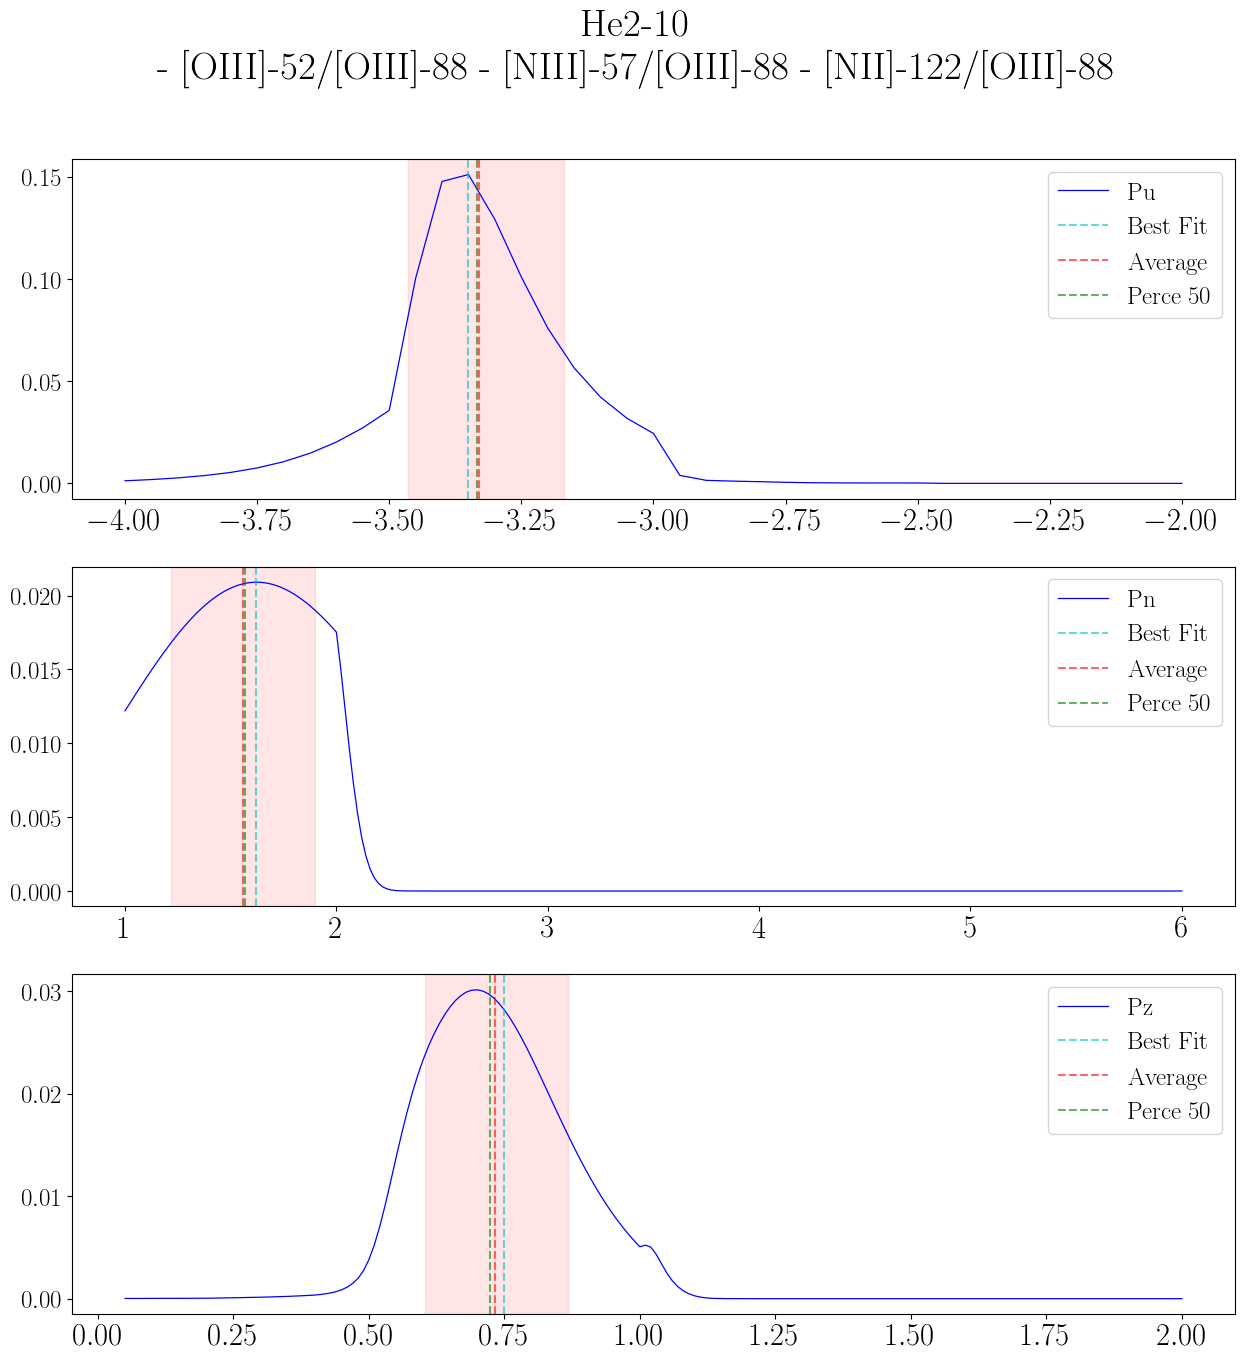

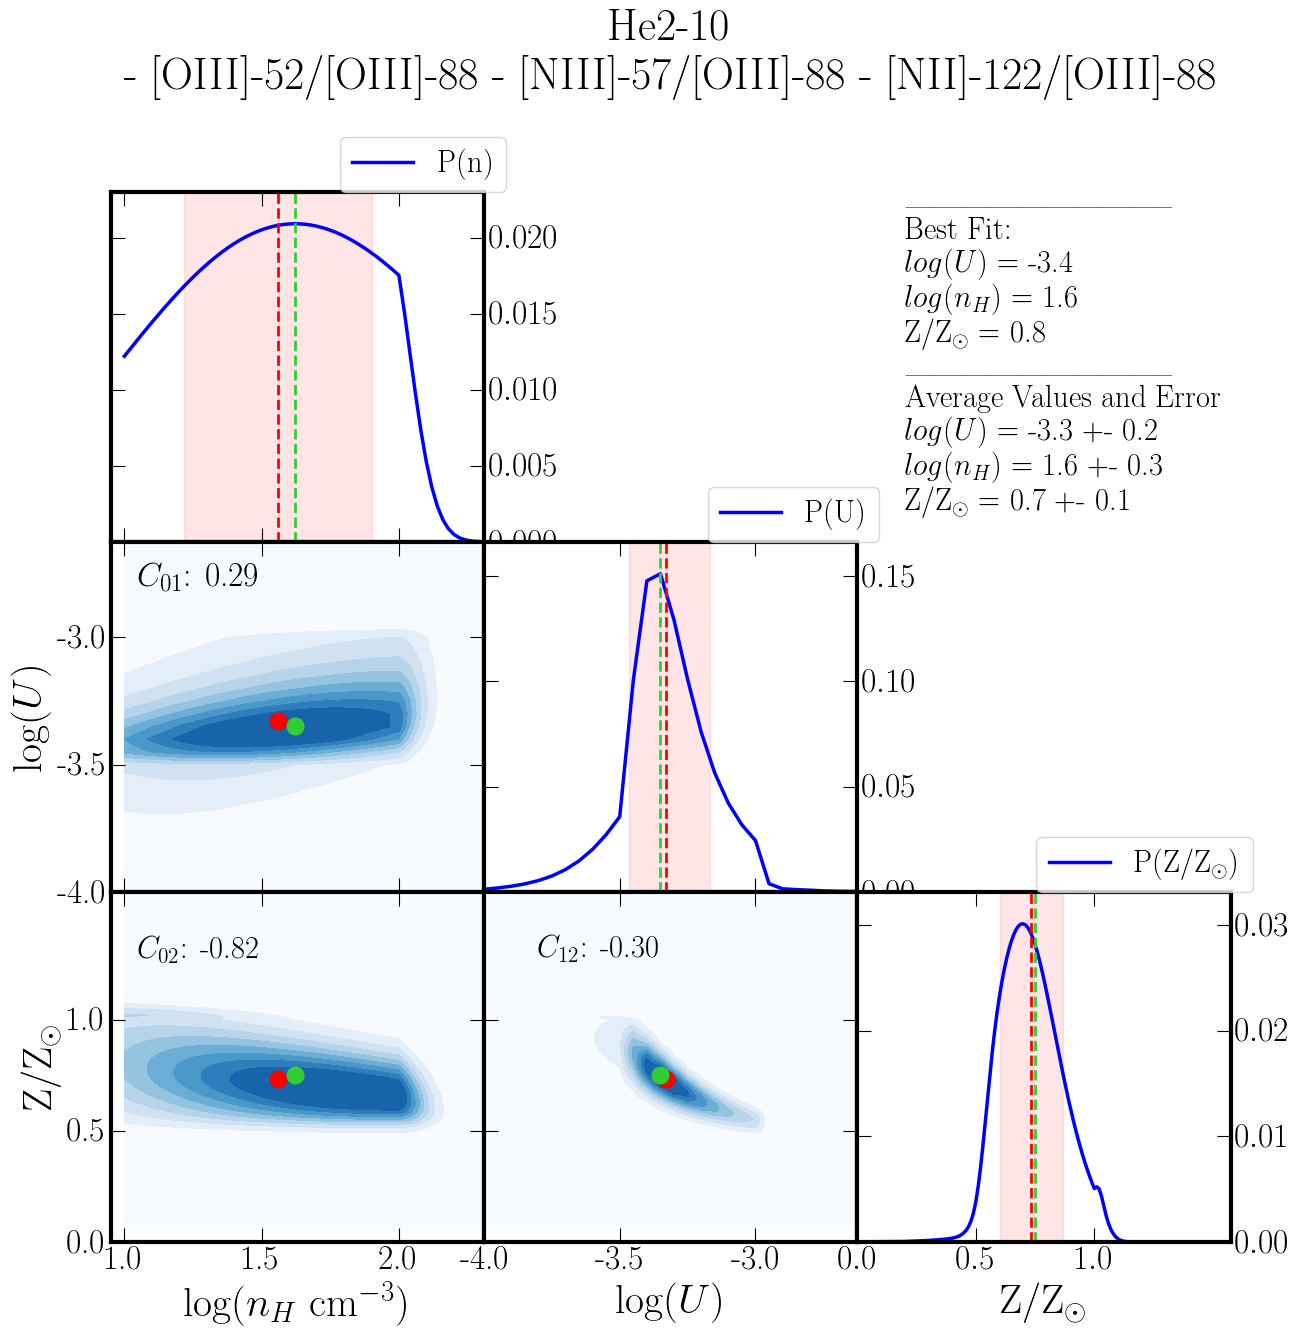

In [40]:
# ----------------------------------------------------------------------
#
#
#      Get Solutions and do the TrianglePlots (Corner plots)
#
#
# ----------------------------------------------------------------------
plt_title = name+TxtLines #+notes

GetSolutions(Prob, Pu, Pn, Pz, uidx, nidx, zidx,  u_grid, n_grid, z_grid,  pltFileName1, pltFileName2,
              plt_title, SummaryFile, name, FluxData, TxtLinesShort )







#
#
# ----------------------------------------------------
#
#

# 














